# Coding Challenge: Learning a Sigmoid Window

In this notebook we construct a simple model that approximates a window-shaped region using two sigmoid functions. The idea is that one sigmoid activates the region while the other suppresses it.

The parameters controlling the shape of the window are trained using gradient descent by minimizing the mean squared error between the model prediction and the generated labels.

Steps performed in this notebook:

1. Generate synthetic labelled data.
2. Define the sigmoid activation function.
3. Train parameters using gradient descent.
4. Visualize the learned function and training loss.

## Sigmoid Function

The sigmoid activation function is defined as

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

This function maps any real number to a value between 0 and 1. Because of this property, it is widely used in machine learning models that require probabilistic interpretations.

Some important properties of the sigmoid function are:

• It is continuous and differentiable everywhere.  
• It smoothly approximates a step function.  
• Its derivative has a simple analytical form.

The derivative of the sigmoid function is

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

This expression makes gradient-based optimization efficient.

## Window Approximation Using Sigmoid Functions

A rectangular window can be approximated using the difference of two sigmoid functions.

The model used in this notebook is

$$
f(x) = \sigma(a(x-b)) - \sigma(a(x-c))
$$

Here the parameters have the following interpretations:

- $a$ controls how steep the transition is.
- $b$ determines the location of the left boundary.
- $c$ determines the location of the right boundary.

The first sigmoid activates the function near $b$, while the second sigmoid suppresses the output after $c$. The difference of the two therefore produces a smooth approximation of a window-shaped function.

## Loss Function

To train the model parameters, we minimize the Mean Squared Error (MSE) between the predicted output and the observed labels.

The loss function is defined as

$$
L = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where

- $y_i$ represents the true label
- $\hat{y}_i$ represents the predicted value of the model

Minimizing this loss encourages the model predictions to closely match the observed data.

## Gradient Descent Optimization

The parameters are updated using gradient descent.

The general update rule for a parameter $\theta$ is

$$
\theta_{new} = \theta_{old} - \eta \frac{\partial L}{\partial \theta}
$$

where

- $\eta$ is the learning rate
- $\frac{\partial L}{\partial \theta}$ is the gradient of the loss function

By repeatedly updating the parameters using this rule, the model gradually learns the optimal values that minimize the loss.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
# Generate synthetic data
x_vals = np.linspace(1,20,100)
labels = []

for val in x_vals:

    if val < 5:
        labels.append(0)

    elif 5 < val < 7.5:
        labels.append(np.random.randint(0,2))

    elif 7.5 < val < 12.5:
        labels.append(1)

    elif 12.5 < val < 15:
        labels.append(np.random.randint(0,2))

    else:
        labels.append(0)

labels = np.array(labels)

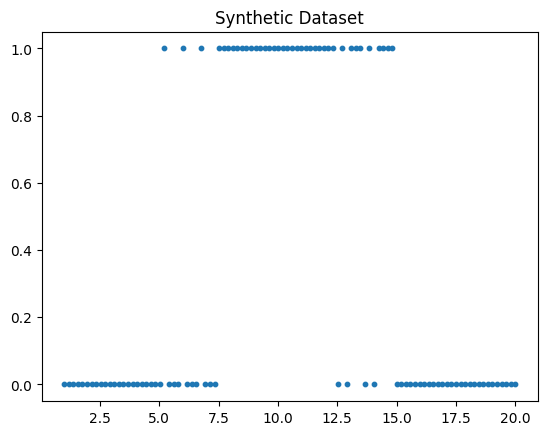

In [4]:
# Plot dataset
plt.scatter(x_vals,labels,s=10)
plt.title("Synthetic Dataset")
plt.show()

In [5]:
# Sigmoid function
def logistic(z):
    return 1/(1+np.exp(-z))

In [6]:
# Initialize parameters
alpha = 3
left_boundary = 10
right_boundary = 12

learning_rate = 0.05
iterations = 5000

loss_values = []

In [7]:
# Gradient descent
for step in range(iterations):

    sig_left = logistic(alpha*(x_vals-left_boundary))
    sig_right = logistic(alpha*(x_vals-right_boundary))

    predictions = sig_left - sig_right

    loss = np.mean((labels-predictions)**2)
    loss_values.append(loss)

    d_left = sig_left*(1-sig_left)
    d_right = sig_right*(1-sig_right)

    grad_alpha = np.mean(
        -2*(labels-predictions)*(d_left*(x_vals-left_boundary)-d_right*(x_vals-right_boundary))
    )

    grad_left = np.mean(-2*(labels-predictions)*(-alpha*d_left))

    grad_right = np.mean(-2*(labels-predictions)*(alpha*d_right))

    alpha -= learning_rate*grad_alpha
    left_boundary -= learning_rate*grad_left
    right_boundary -= learning_rate*grad_right

In [8]:
# Final prediction
final_prediction = logistic(alpha*(x_vals-left_boundary)) - logistic(alpha*(x_vals-right_boundary))

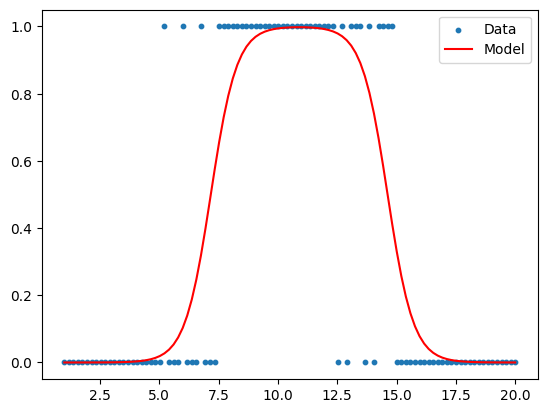

In [9]:
# Plot model fit
plt.scatter(x_vals,labels,s=10,label="Data")
plt.plot(x_vals,final_prediction,color="red",label="Model")
plt.legend()
plt.show()

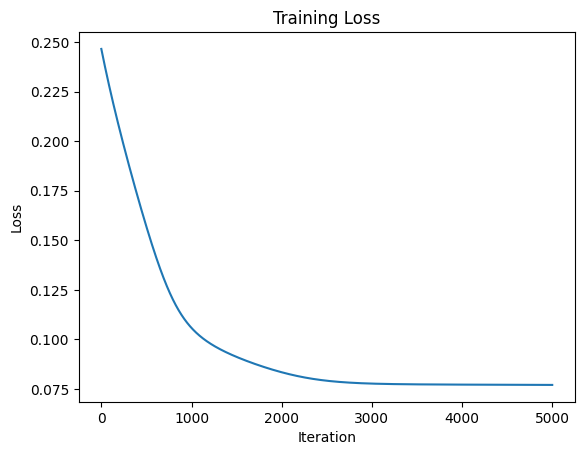

In [10]:
# Loss curve
plt.plot(loss_values)
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## Results

After running gradient descent, the model learns parameters that approximate the target window in the data.

The predicted curve shows that the model successfully identifies the region where the output should be close to one while remaining near zero outside this interval.

The decreasing loss curve also indicates that the optimization process converges effectively.